# Programación probabilista


**Importamos las funcionalidades necesarias:**

Ejecutar esta celda solo en caso de usar Google Colab y tener problemas con las extensiones instaladas en el entorno (en caso contrario, ejecutar la celda siguiente directamente):

In [ ]:
# ==========================
# Entorno estable para PyMC + PreliZ en Colab
# ==========================

!pip uninstall -y \
    preliz \
    pytensor \
    pytensor-distributions \
    arviz_stats \
    numba \
    llvmlite

!pip install -U --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.16.1" \
    "pandas==2.3.0" \
    "matplotlib==3.10.0" \
    "llvmlite==0.43.0" \
    "numba==0.60.0" \
    "arviz==0.22.0" \
    "pymc==5.28.5" \
    "pytensor==2.38.3" \
    "arviz_stats==0.6.0" \
    "preliz==0.20.0"
# sigan estos pasos:
print("\n==============================")
print("IMPORTANTE")
print("Ahora hacé Runtime > Restart session")
print("y recién después ejecutá las celdas del notebook.")
print("==============================")

Found existing installation: pytensor 2.38.3
Uninstalling pytensor-2.38.3:
  Successfully uninstalled pytensor-2.38.3
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 313.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 270.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 273.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 277.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 301.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 387.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 297.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [1]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-doc")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\preliz\ppls\pymc_io.py:12: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


# Accidentes mineros

veamos un ejemplo del tutorial de PyMC, que pueden encontrar completo en el siguiente [link.](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/pymc_overview.html#case-study-2-coal-mining-disasters)

En este ejemplo analizaremos un conjunto de datos que registra la cantidad de accidentes ocurridos en minas de carbón del Reino Unido entre 1851 y 1962. Se busca determinar si la implementación de nuevas medidas de seguridad produjo un cambio en la tasa de accidentes y, en caso afirmativo, estimar el momento en que dicho cambio ocurrió.

El conjunto de datos contiene la cantidad de accidentes registrados cada año y presenta algunos valores NaN, que representan datos faltantes. En un enfoque bayesiano, estos valores pueden tratarse como parámetros desconocidos del modelo y estimarse junto con el resto de las cantidades de interés, evitando así descartar información disponible.

In [2]:
accidentes = pd.Series([4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
                       3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
                       2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,
                       1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
                       0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
                       3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
                       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1])
años = np.arange(1851, 1962)

En primer lugar vamos a trabajar con un ploteo de núnmero de accidentes según cada año:

C:\Users\MAURICIO\AppData\Local\Temp\ipykernel_8128\2510285102.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


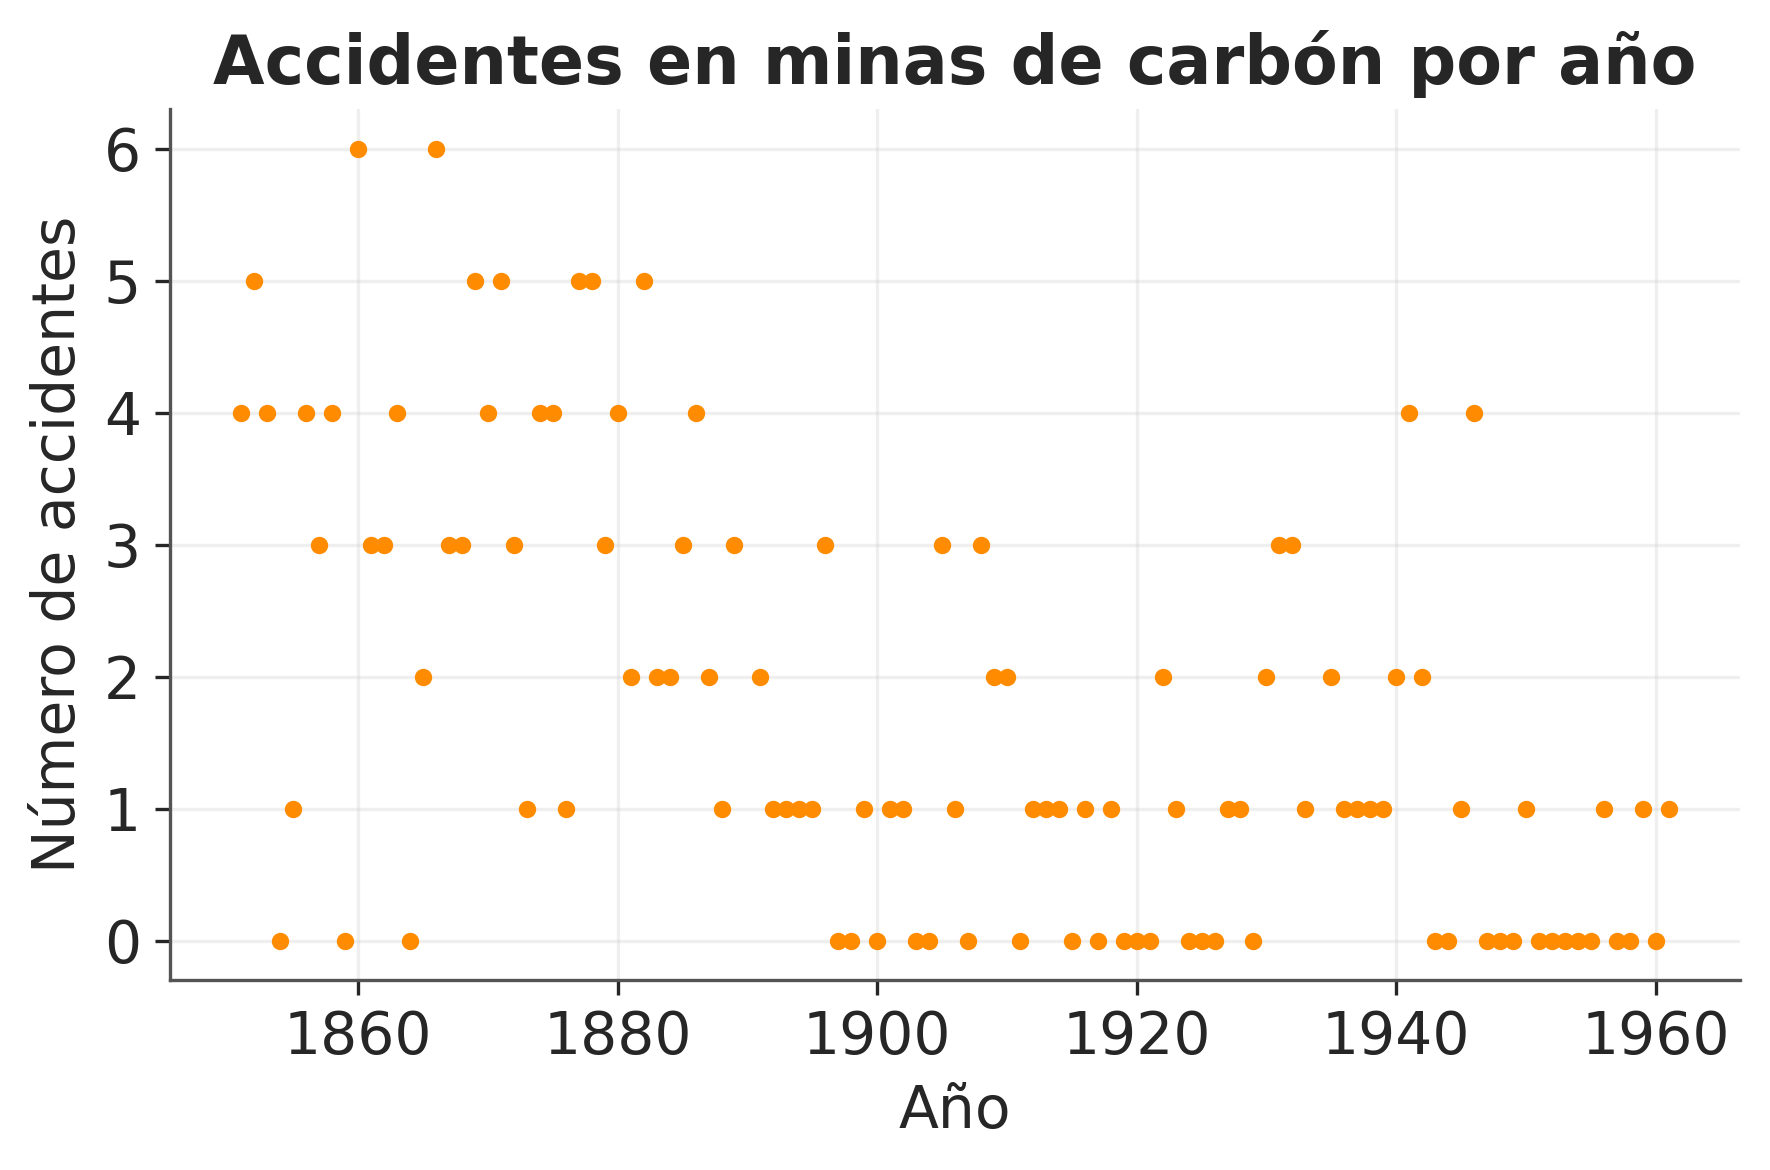

In [3]:
plt.figure(figsize=(6,4))

plt.scatter(
    años,
    accidentes,
    color="darkorange",
    s=10
)

plt.xlabel("Año")
plt.ylabel("Número de accidentes")
plt.title("Accidentes en minas de carbón por año")
plt.grid(alpha=0.3)
plt.tight_layout()

**Creación del modelo:**

trabajaremos con una distribución de Poisson, y teniendo en cuenta que creemos que la cantidad media de accidentes es distinta antes y después de la introducción de regulaciones de seguridad, debemos incluir de alguna manera esta diferencia:

planteamos dos tasas medias de accidentes distitnas, que llamamos $t_0$ y $t_1$, y la estimación del punto de corte $p_{c}$ que nos perimitirá dividir los años para los cuales se aplica la tasa de accidentes $t_0$ de los cuales se aplica la tasa $t_1$.

El modelo nos queda:

\begin{equation}
A_t \sim Poisson(tasa)
\end{equation}

\begin{equation}
tasa = \begin{cases}
t_0, \text{si } t \ge pc,\\
t_1, \text{si } t \lt pc
\end{cases}
\end{equation}

con *priors*

\begin{align}
t_0 \sim Expon(1) \\
t_1 \sim Expon(1) \\
p_c \sim U(A_0, A_1)
\end{align}




Observación: la distribución uniforme es discreta y $A_0$ y $A_1$ son el primer y último año.

Ahora sí, pasamos a plantear nuestro modelo desde el punto de vista computacional usando PyMC:

In [4]:
with pm.Model() as modelo_cat:

    pc = pm.DiscreteUniform("pc", lower=años.min(), upper=años.max())

    # Definimos los priors t0 y t1:
    t_0 = pm.Exponential("t_0", 1)
    t_1 = pm.Exponential("t_1", 1)

    # Asignamos las tasas a los años de acuerdo al p_c:
    tasa = pm.Deterministic("tasa", pm.math.switch(pc >= años, t_1, t_0))

    acc = pm.Poisson("acc", tasa, observed=accidentes)
    idata_cat = pm.sample(1000, random_seed=1791, idata_kwargs={"log_likelihood": True})

c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\pymc\model\core.py:1304: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\pymc\model\core.py:1318: ImputationWarning: Data in acc contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Metropolis: [pc]
>>Metropolis: [acc_unobserved]
>NUTS: [t_0, t_1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 104 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Observación: la función `pm.switch`nos indica que si el argumento es _True_ nos va a devolver el segundo argumento, si es _False_ nos devolverá el tercer argumento.

Como resultado tenemos que _tasa_ es un vector de longitud igual a la de _años_ y cuyos elementos corresponden a una repetición $t_0$ seguida de una repetición $t_1$, la cantidad exacta de repeticiones de $t_0$ y $t_1$ está controlada por la condición $pc \ge$ _años_. De esta forma, podemos al muestrear $p_c$, modificar que años reciben cual tasa para el cálculo del _likelihood_.

In [5]:
idata_cat # verificamos rápidamente que el muestreo se realizó correctamente y qué información quedó almacenada en el objeto.

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

El siguiente gráfico representa las distribuciones posteriores de los parámetros asociados a las tasas de accidentes antes y después del cambio en el modelo. A partir de las muestras obtenidas mediante MCMC, se visualiza la incertidumbre asociada a cada parámetro y el intervalo de máxima densidad (HDI) correspondiente. La comparación entre ambas distribuciones permite analizar si existe evidencia de una modificación en la tasa de accidentes luego de la implementación de las medidas de seguridad.



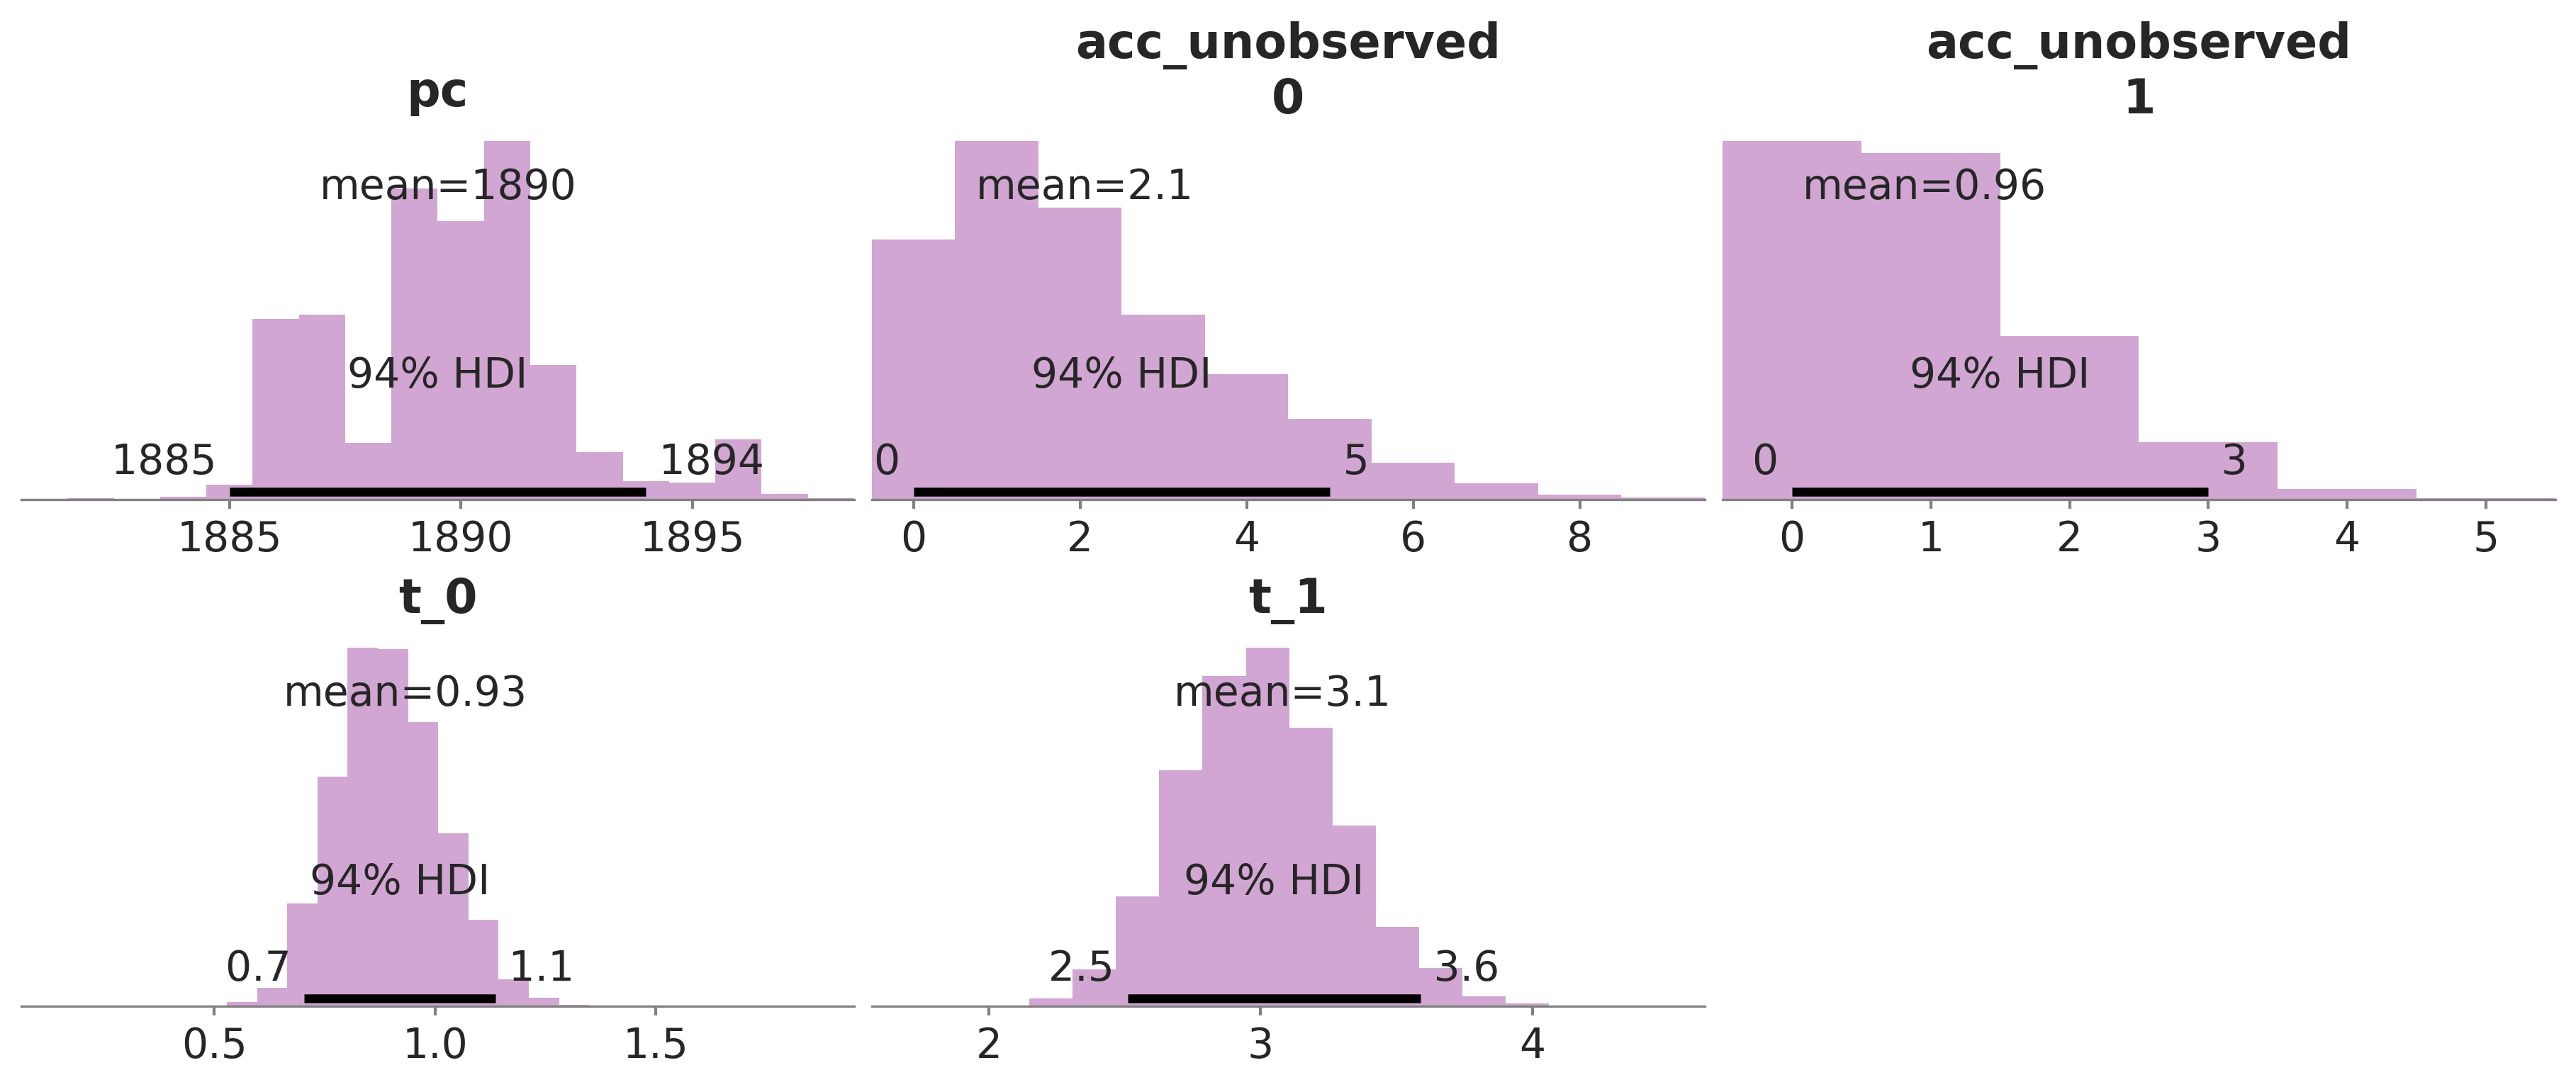

In [6]:
az.plot_posterior(
    idata_cat,
    var_names=["~tasa", "~acc"],
    hdi_prob=0.94,
    figsize=(12, 5),
    point_estimate="mean",
    kind="hist",
    color="purple"
);

In [7]:
az.summary(idata_cat, kind="stats", var_names=["~tasa", "~acc"])

,mean,sd,hdi_3%,hdi_97%
pc,1889.718,2.460,1885.000,1894.000
acc_unobserved[0],2.052,1.731,0.000,5.000
acc_unobserved[1],0.956,0.964,0.000,3.000
t_0,0.932,0.118,0.703,1.138
t_1,3.081,0.290,2.511,3.587


Visualizamos y analizamos:

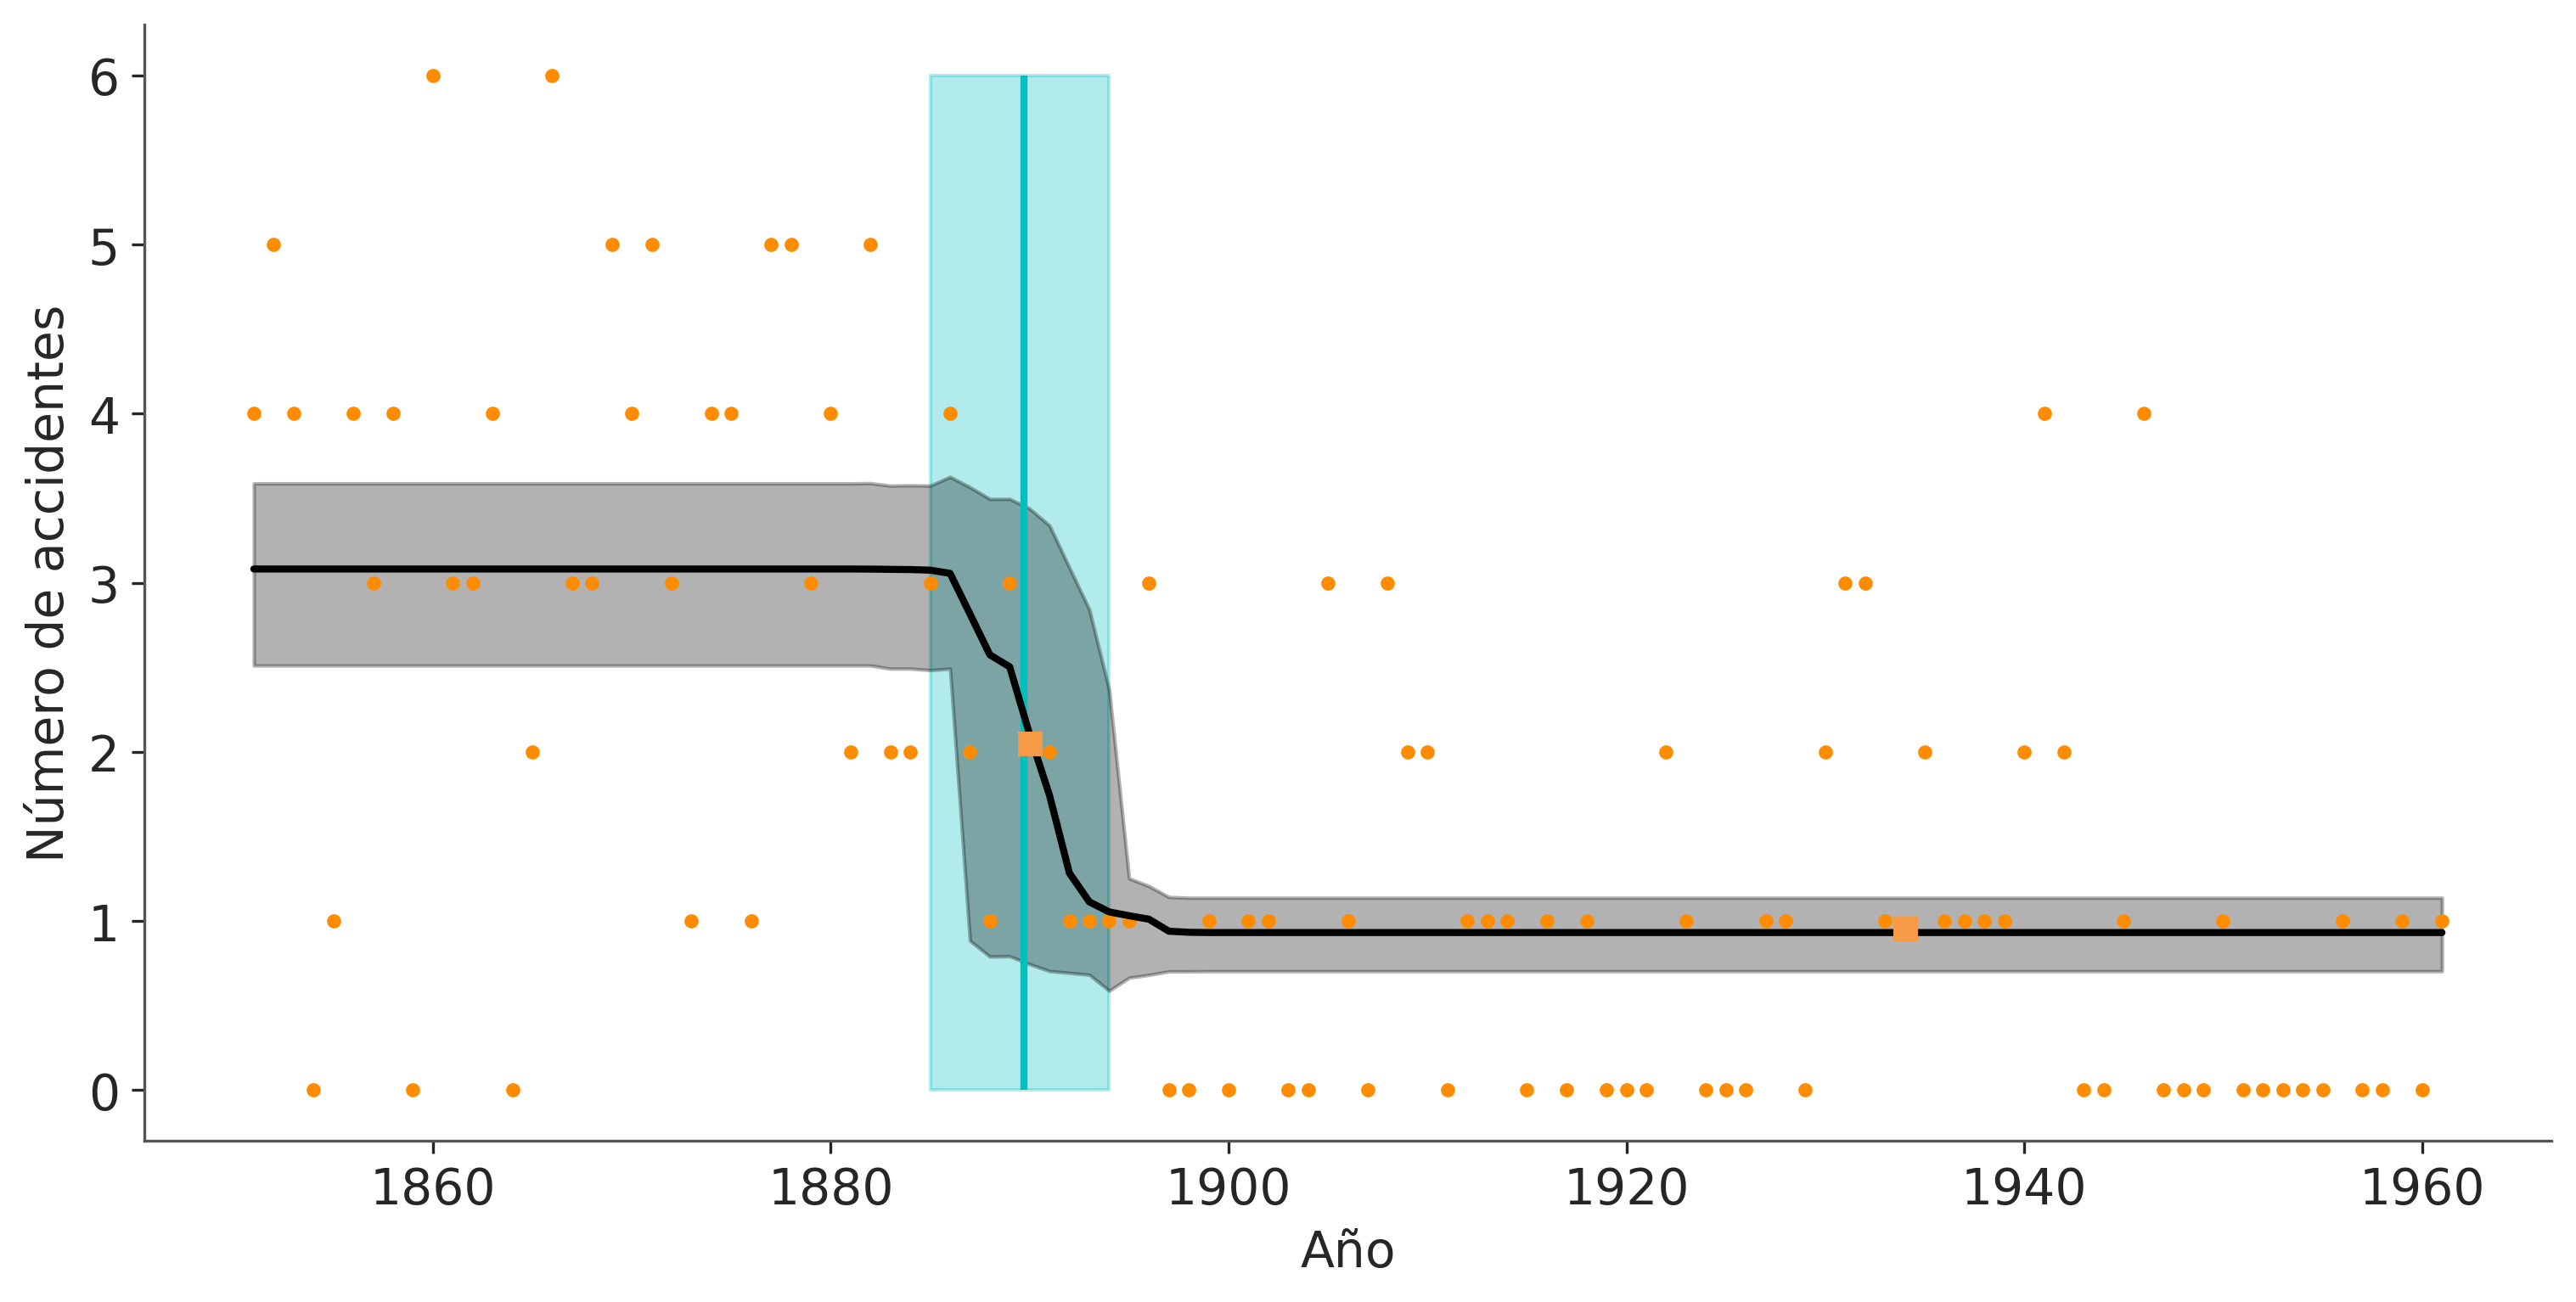

In [8]:
tasa_mean = idata_cat.posterior["tasa"].mean(("chain", "draw"))
tasa_hdi = az.hdi(idata_cat.posterior["tasa"].values)
pc_hdi = az.hdi(idata_cat.posterior["pc"])["pc"]

_, ax = plt.subplots(figsize=(10, 5), sharey=True)
ax.plot(años, accidentes, ".", color="darkorange")

ax.set_ylabel("Número de accidentes")
ax.set_xlabel("Año")

ax.vlines(
    idata_cat.posterior["pc"].mean(("chain", "draw")),
    accidentes.min(),
    accidentes.max(),
    color="C1",
    lw=2,
)


ax.fill_betweenx(
    [accidentes.min(), accidentes.max()], pc_hdi[0], pc_hdi[1], alpha=0.3, color="C1"
)
ax.plot(años, tasa_mean, "k", lw=2)
ax.fill_between(años, tasa_hdi[:, 0], tasa_hdi[:, 1], alpha=0.3, color="k")


faltante0 = (
    idata_cat.posterior["acc_unobserved"].sel(acc_unobserved_dim_0=0).mean(("chain", "draw"))
)
faltante1 = (
    idata_cat.posterior["acc_unobserved"].sel(acc_unobserved_dim_0=1).mean(("chain", "draw"))
)

ax.plot(años[np.isnan(accidentes)], [faltante0, faltante1], "C2s");